## Imports

In [14]:
import numpy as np
import pandas as pd
import matplotlib.cm as cm
import matplotlib.pyplot as plt

In [15]:
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "lines.linewidth": 1.2,
    "legend.frameon": False,
    "savefig.dpi": 600,
    "figure.dpi": 150
})

## Single Run Analysis

In [13]:
df = pd.read_csv("/home/cmp/Documents/Github/Stoner-SCF/out/find_gs.csv")
df = df[np.abs(df['Energy']) > 1e-3]
df = df.sort_values(by="Energy", ascending=True)
df.columns = df.columns.str.strip()

orbitals = ["yz", "zx", "xy"]
spins = ["up", "down"]
layers = [1, 2]
moment_labels = ["Lx", "Ly", "Lz", "L110", "Sx", "Sy", "Sz", "S110"]

# --- Formatted text summaries ---

def mag_angles(x, y, z):
    mag = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arccos(z / mag) if mag != 0 else 0.0
    phi = np.arctan2(y, x)
    return mag, theta/np.pi, phi/np.pi

def mag_angles_row(row, layer):
    Lmag, Ltheta, Lphi =  mag_angles(row[f"{layer}_Lx"], row[f"{layer}_Ly"], row[f"{layer}_Lz"])
    Smag, Stheta, Sphi =  mag_angles(row[f"{layer}_Sx"], row[f"{layer}_Sy"], row[f"{layer}_Sz"])
    return Lmag, Ltheta, Lphi, Smag, Stheta, Sphi

def occupation_table(row):
    data = {}
    for layer in layers:
        for spin in spins:
            data[f"L{layer} {spin}"] = [row[f"occ{layer}_{orb}_{spin}"] for orb in orbitals]
    t = pd.DataFrame(data, index=orbitals)
    t["L1 tot"] = t["L1 up"] + t["L1 down"]
    t["L2 tot"] = t["L2 up"] + t["L2 down"]
    t.loc["Total"] = t.sum()
    return t

def moment_table(row):
    data = {
        "Layer 1": [row[f"O1_{lab}"] for lab in moment_labels],
        "Layer 2": [row[f"O2_{lab}"] for lab in moment_labels],
    }
    return pd.DataFrame(data, index=moment_labels)


def add_momentum_angles(row):
    row["O1_Lmag"], row["O1_Ltheta"], row["O1_Lphi"], row["O1_Smag"], row["O1_Stheta"], row["O1_Sphi"] = mag_angles_row(row, "O1")
    row["O2_Lmag"], row["O2_Ltheta"], row["O2_Lphi"], row["O2_Smag"], row["O2_Stheta"], row["O2_Sphi"] = mag_angles_row(row, "O2")
    return row

def print_seed_summary(row):
    print(f"\n===== Seed {int(row['Seed'])}  "
            f"(E = {row['Energy']:.6f}, Threshold = {row['Threshold']:.1e}, "
            f"Rho2Trace = {row['Rho2Trace']:.6f}) =====")
    print("\nOccupations:")
    print(occupation_table(row).round(4).to_string())
    print("\nOrbital (L) and spin (S) moments:")
    print(moment_table(row).round(4).to_string())   
    print(pd.DataFrame([mag_angles_row(row, "O1")], columns=["Lmag", "Ltheta", "Lphi", "Smag", "Stheta", "Sphi"]).round(4).to_string(index=False))
    print(pd.DataFrame([mag_angles_row(row, "O2")], columns=["Lmag", "Ltheta", "Lphi", "Smag", "Stheta", "Sphi"]).round(4).to_string(index=False))


FileNotFoundError: [Errno 2] No such file or directory: '/home/cmp/Documents/Github/Stoner-SCF/out/find_gs.csv'

In [ ]:
print_seed_summary(df.iloc[2])


===== Seed 5  (E = 21.722503, Threshold = 1.0e-07, Rho2Trace = 7.251471) =====

Occupations:
        L1 up  L1 down   L2 up  L2 down  L1 tot  L2 tot
yz     0.7406   0.7995  0.5438   0.6474  1.5401  1.1912
zx     0.7406   0.7995  0.5438   0.6474  1.5401  1.1912
xy     0.4699   0.5903  0.7052   0.7721  1.0602  1.4773
Total  1.9511   2.1892  1.7928   2.0669  4.1403  3.8597

Orbital (L) and spin (S) moments:
      Layer 1  Layer 2
Lx     0.0000  -0.0000
Ly     0.0000  -0.0000
Lz    -0.6858  -0.0041
L110   0.0000  -0.0000
Sx     0.0286   0.0329
Sy     0.9217   1.0608
Sz    -0.1191  -0.1370
S110   0.6720   0.7734
  Lmag  Ltheta   Lphi   Smag  Stheta   Sphi
0.6858     1.0 0.4941 0.9298  0.5409 0.4901
  Lmag  Ltheta    Lphi   Smag  Stheta   Sphi
0.0041     1.0 -0.8495 1.0702  0.5409 0.4901


In [ ]:
# Ground state data set
df_gs = df[df['Threshold'] <= 1e-1]
df_gs = df_gs[np.abs(df_gs['Energy'] - df_gs['Energy'].min()) <= 1e-7]
df_gs = df_gs.apply(add_momentum_angles, axis=1)

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

idx = {'i': 0}
out = widgets.Output()

def show():
    with out:
        clear_output(wait=True)
        print(f"[{idx['i']+1}/{len(df)}]\n")
        print_seed_summary(df_gs.iloc[idx['i']])

def on_prev(b):
    idx['i'] = max(0, idx['i'] - 1)
    show()

def on_next(b):
    idx['i'] = min(len(df_gs) - 1, idx['i'] + 1)
    show()

prev_btn = widgets.Button(description="◀ Prev")
next_btn = widgets.Button(description="Next ▶")
prev_btn.on_click(on_prev)
next_btn.on_click(on_next)

display(widgets.HBox([prev_btn, next_btn]), out)
show()

Output()

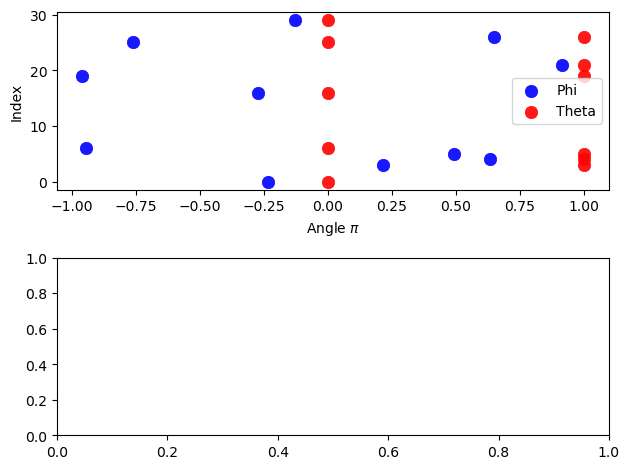

In [ ]:
fig, axs = plt.subplots(2, 1)

# phi is the angular coordinate, theta is the radial coordinate
theta = df_gs["O1_Ltheta"]   # or Stheta, in radians
phi = df_gs["O1_Lphi"]       # in radians

sc_phi = axs[0].scatter(
    phi,df_gs.index,
    s=80,
    c="blue",
    linewidth=0.5,
    alpha=0.9,
)

sc_theta = axs[0].scatter(
    theta,df_gs.index,
    s=80,
    c="red",
    linewidth=0.5,
    alpha=0.9,
)

axs[0].set_xlabel("Angle $\\pi$")
axs[0].set_ylabel("Index")
axs[0].legend([sc_phi, sc_theta], ["Phi", "Theta"])
plt.tight_layout()

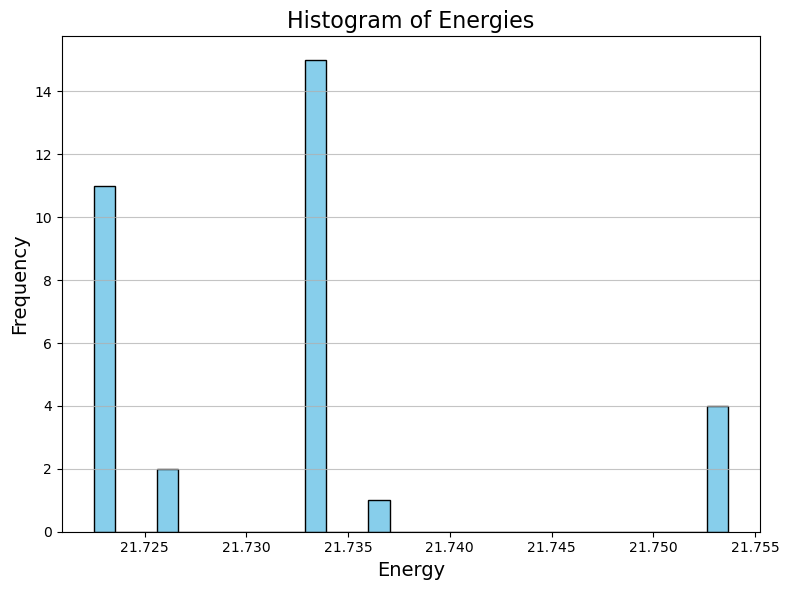

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(df['Energy'], bins=30, color='skyblue', edgecolor='black')

ax.set_title('Histogram of Energies', fontsize=16)
ax.set_xlabel('Energy', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()

/tmp/ipykernel_954787/1917668191.py:9: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


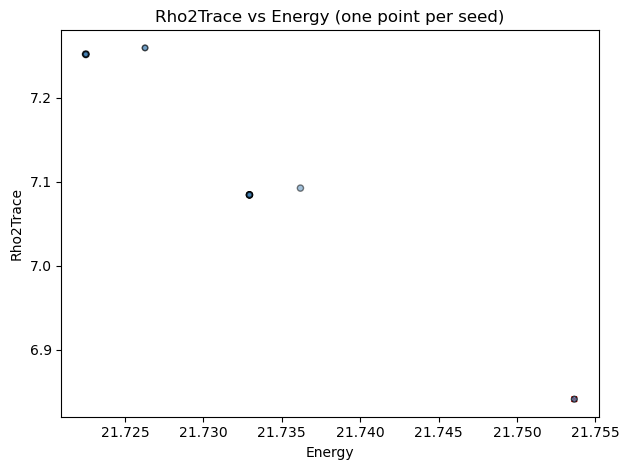

In [ ]:
colors = np.where(df["Seed"] < 0, "red", "steelblue")
sizes = 100 * -1/np.log10(df["Threshold"])

fig, ax = plt.subplots()

neg = df["Seed"] < 0
pos = ~neg

ax.scatter(
    df["Energy"][neg], df["Rho2Trace"][neg],
    s=sizes[neg], alpha=1, marker="x",
    edgecolor="black", linewidth=1, color="red",
)
ax.scatter(
    df["Energy"][pos], df["Rho2Trace"][pos],
    s=sizes[pos], alpha=0.5, marker="o",
    edgecolor="black", linewidth=1, color="steelblue",
)

ax.set_xlabel("Energy")
ax.set_ylabel("Rho2Trace")
ax.set_title("Rho2Trace vs Energy (one point per seed)")

plt.tight_layout()
plt.savefig("energy_vs_rho2trace_scatter.png", dpi=150)
plt.show()

In [ ]:
df_sort_tresh = df.sort_values(by="Threshold", ascending=True)
print(df_sort_tresh.iloc[11]['Energy'])
print(df_sort_tresh.iloc[0]['Energy'])
print(df_sort_tresh.iloc[1]['Energy'] - df_sort_tresh.iloc[0]['Energy'])

21.72627997
21.72250323
0.0


## Sweeping N electron Analysis

In [ ]:
def analyze_output(ffolder, fpath):
    df = pd.read_csv(ffolder + fpath)
    # Filtered Unconverged
    df = df[np.abs(df['Energy']) > 1e-3]
    df = df[np.abs(df['Energy']) < 1e10]

    n_bins = 5
    df['energy_bin'] = pd.cut(df['Energy'], bins=n_bins)

    # Count how many fall in each bin
    counts = df['energy_bin'].value_counts().sort_index()

    # Count just the lowest energy bin
    lowest_bin_count = counts.iloc[0]
    total_count = len(df)
    lowest_energy = df['Energy'].min()

    return lowest_energy, lowest_bin_count, total_count

def returnMCA(ffolder):
    rows = []
    for N in [8.0, 8.25, 8.5, 8.75, 9.0]:
        for spin_dir in ["001", "110"]:
            fpath = f"/{spin_dir}gsoutN={N}.csv"
            lnE, lnBinLowest, totCount = analyze_output(ffolder, fpath)
            rows.append({
                'N': N,
                'spin_dir': spin_dir,
                'LowestEnergy': lnE,
                'LowestBinCount': lnBinLowest,
                'TotalCount': totCount
            })
    dfMCA = pd.DataFrame(rows)
    return dfMCA

def computeMCAList(ffolder):
    dfMCA = returnMCA(ffolder)
    
    MCA = []
    for N in sorted(dfMCA['N'].unique()):
        e001 = dfMCA.loc[(dfMCA['N'] == N) & (dfMCA['spin_dir'] == "001"), 'LowestEnergy'].values[0]
        e110 = dfMCA.loc[(dfMCA['N'] == N) & (dfMCA['spin_dir'] == "110"), 'LowestEnergy'].values[0]
        MCA.append(e001 - e110)
    
    return MCA # Convert to meV


ffolder = "/home/cmp/Documents/Github/Stoner-SCF/out/sweeps/8to9Sweep"
dfMCA = returnMCA(ffolder)

MCAList = computeMCAList(ffolder)

dfMCA

,N,spin_dir,LowestEnergy,LowestBinCount,TotalCount
0,8.00,001,21.709116,27,34
1,8.00,110,21.721209,26,35
2,8.25,001,23.829790,29,35
3,8.25,110,23.840017,29,34
4,8.50,001,25.974429,33,34
5,8.50,110,25.982761,29,32
6,8.75,001,28.174120,34,35
7,8.75,110,28.180485,27,32
8,9.00,001,30.421308,34,35
9,9.00,110,30.425469,30,33


In [ ]:
MCAList

[np.float64(-0.01209257000000008),
 np.float64(-0.01022734000000014),
 np.float64(-0.008332760000001826),
 np.float64(-0.006365439999999722),
 np.float64(-0.004160389999999126)]

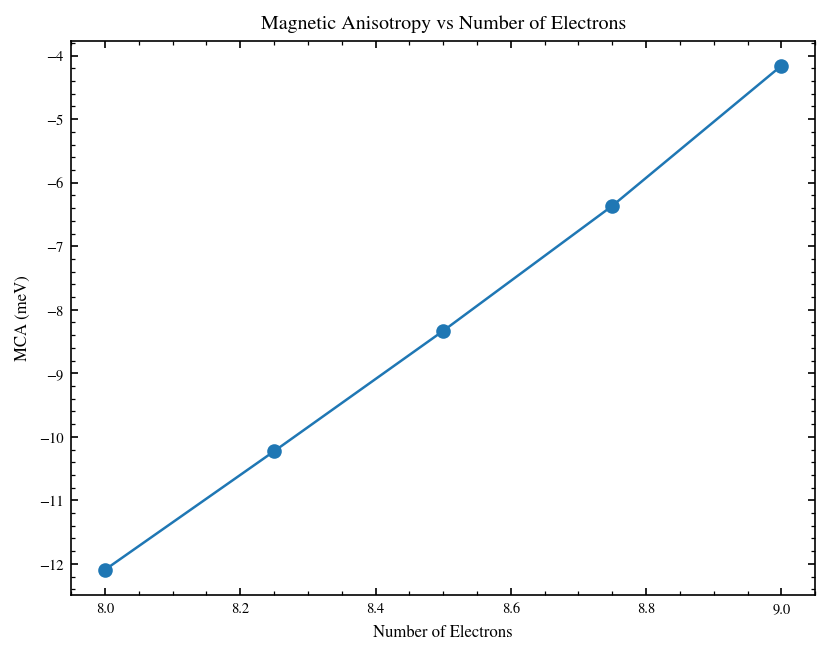

In [ ]:
fig, ax = plt.subplots()

nelectron = [8.0, 8.25, 8.5, 8.75, 9.0]
ax.plot(nelectron, np.array(MCAList)*1e3, marker='o')

ax.set_xlabel('Number of Electrons')
ax.set_ylabel('MCA (meV)')
ax.set_title('Magnetic Anisotropy vs Number of Electrons')
plt.show()

In [ ]:
import os
from pathlib import Path

def get_gs_row(ffolder, fpath):
    df = pd.read_csv(Path(ffolder) / fpath.lstrip("/"))
    df = df[(np.abs(df["Energy"]) > 1e-3) & (np.abs(df["Energy"]) < 1e10)].copy()

    if df.empty:
        raise ValueError(f"No converged rows in {fpath}")

    gs_row = df.loc[df["Energy"].idxmin()]

    n_bins = 5
    df["energy_bin"] = pd.cut(df["Energy"], bins=n_bins)
    counts = df["energy_bin"].value_counts().sort_index()

    return gs_row, counts.iloc[0], len(df)


def analyze_output_row(ffolder, N_values=(8.0, 8.25, 8.5, 8.75, 9.0), spin_dirs=("001", "110")):
    records = []
    for N in N_values:
        for spin_dir in spin_dirs:
            fpath = f"{spin_dir}gsoutN={N}.csv"
            gs_row, lowest_bin_count, total_count = get_gs_row(ffolder, fpath)
            records.append({
                "N": N,
                "spin_dir": spin_dir,
                **gs_row.to_dict(),
                "lowest_bin_count": lowest_bin_count,
                "total_count": total_count,
            })
    return pd.DataFrame(records)

def K1_layer1(row001, row110, SOC):
    K_layer1 = -SOC*(row110["O1_L110"]*row110["O1_Sz"]-row001["O1_Lz"]*row001["O1_Sz"])
    return K_layer1

def K1_layer2(row001, row110, SOC):
    K_layer2 = -SOC*(row110["O2_L110"]*row110["O2_Sz"]-row001["O2_Lz"]*row001["O2_Sz"])
    return K_layer2




In [ ]:
all_gs = analyze_output_row(ffolder)
all_gs.head()

all_gs_001 = all_gs[all_gs["spin_dir"] == "001"]
all_gs_110 = all_gs[all_gs["spin_dir"] == "110"]

k1_results_layer1 = [
    K1_layer1(all_gs_001.iloc[i], all_gs_110.iloc[i], SOC=0.03)
    for i in range(len(all_gs_001))
]

k1_results_layer2 = [
    K1_layer2(all_gs_001.iloc[i], all_gs_110.iloc[i], SOC=0.03)
    for i in range(len(all_gs_001))
]

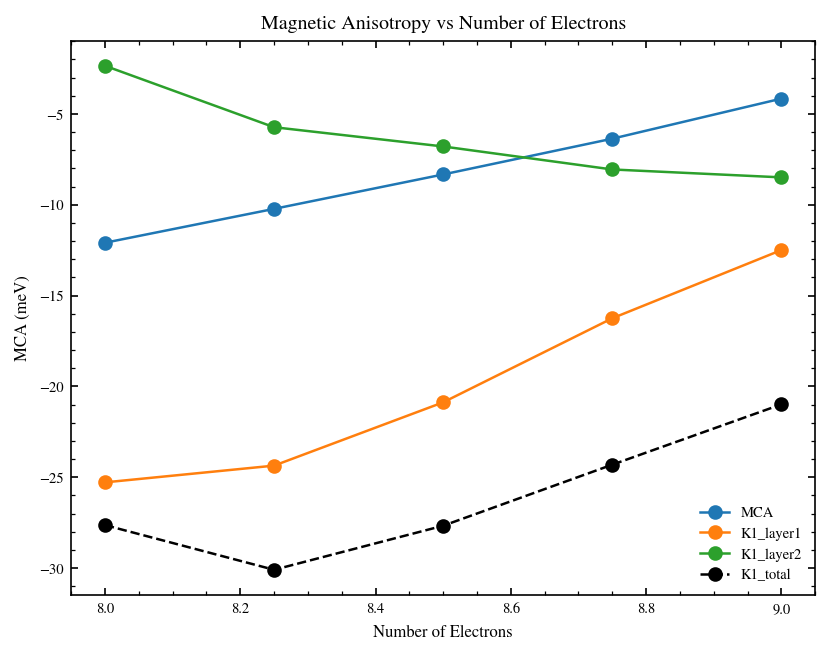

In [ ]:
fig, ax = plt.subplots()

nelectron = [8.0, 8.25, 8.5, 8.75, 9.0]
ax.plot(nelectron, np.array(MCAList)*1e3, marker='o')
ax.plot(nelectron, np.array(k1_results_layer1)*1e3, marker='o')
ax.plot(nelectron, np.array(k1_results_layer2)*1e3, marker='o')
ax.plot(nelectron, np.array(np.array(k1_results_layer1) + np.array(k1_results_layer2))*1e3, marker='o', linestyle='--', c="black")

ax.set_xlabel('Number of Electrons')
ax.set_ylabel('MCA (meV)')
ax.set_title('Magnetic Anisotropy vs Number of Electrons')
ax.legend(["MCA", "K1_layer1", "K1_layer2", "K1_total"])
plt.show()

Text(0.5, 0, 'Number of Electrons (N)')

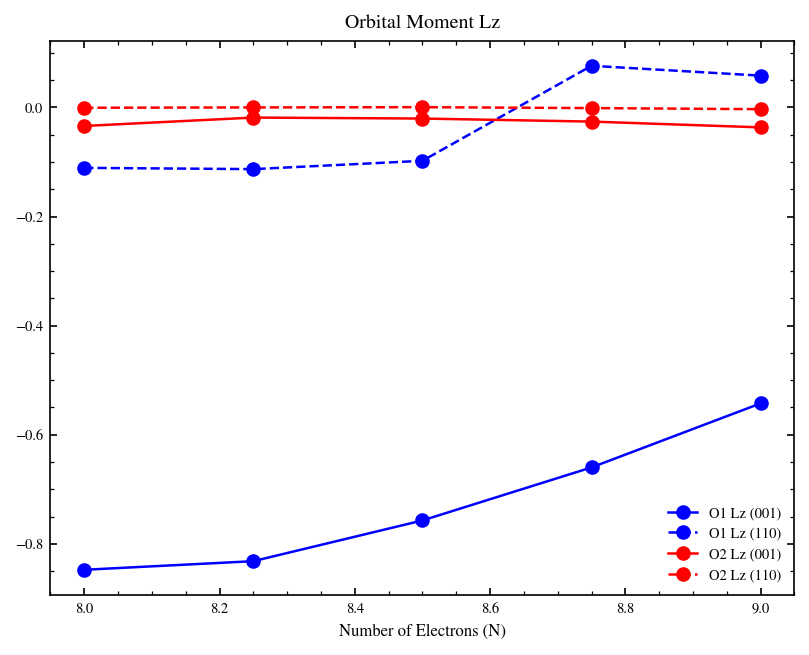

In [ ]:
fig1, ax1 = plt.subplots()

ax1.plot(all_gs_001["N"], all_gs_001["O1_Lz"], marker='o', c="blue")
ax1.plot(all_gs_110["N"], all_gs_110["O1_Lz"], marker='o', linestyle='--', c="blue")
ax1.plot(all_gs_001["N"], all_gs_001["O2_Lz"], marker='o', c="red")
ax1.plot(all_gs_110["N"], all_gs_110["O2_Lz"], marker='o', linestyle='--', c="red")

ax1.set_title("Orbital Moment Lz")
ax1.legend(["O1 Lz (001)", "O1 Lz (110)", "O2 Lz (001)", "O2 Lz (110)"])
ax1.set_xlabel("Number of Electrons (N)")

Text(0.5, 0, 'Number of Electrons (N)')

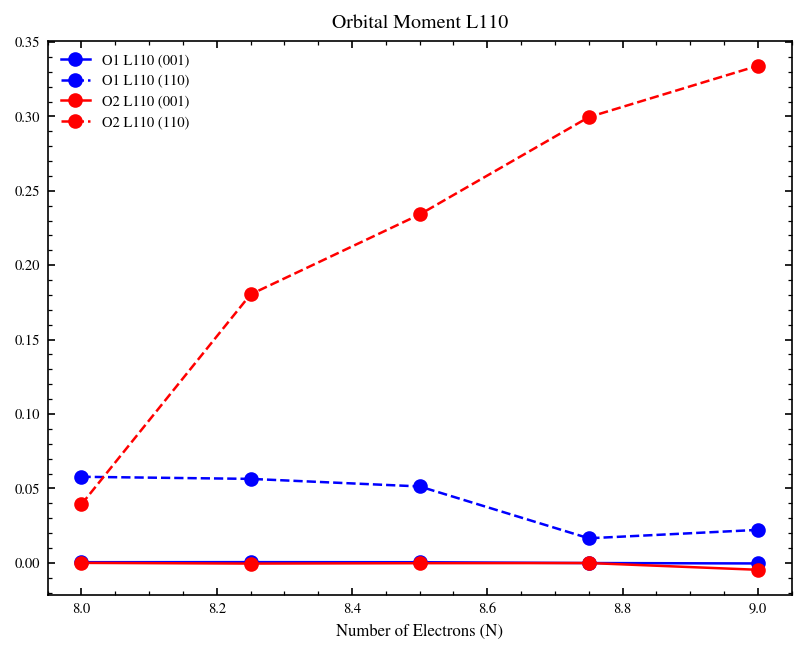

In [ ]:
fig1, ax1 = plt.subplots()

ax1.plot(all_gs_001["N"], all_gs_001["O1_L110"], marker='o', c="blue")
ax1.plot(all_gs_110["N"], all_gs_110["O1_L110"], marker='o', linestyle='--', c="blue")
ax1.plot(all_gs_001["N"], all_gs_001["O2_L110"], marker='o', c="red")
ax1.plot(all_gs_110["N"], all_gs_110["O2_L110"], marker='o', linestyle='--', c="red")

ax1.set_title("Orbital Moment L110")
ax1.legend(["O1 L110 (001)", "O1 L110 (110)", "O2 L110 (001)", "O2 L110 (110)"])
ax1.set_xlabel("Number of Electrons (N)")

Text(0.5, 0, 'Number of Electrons (N)')

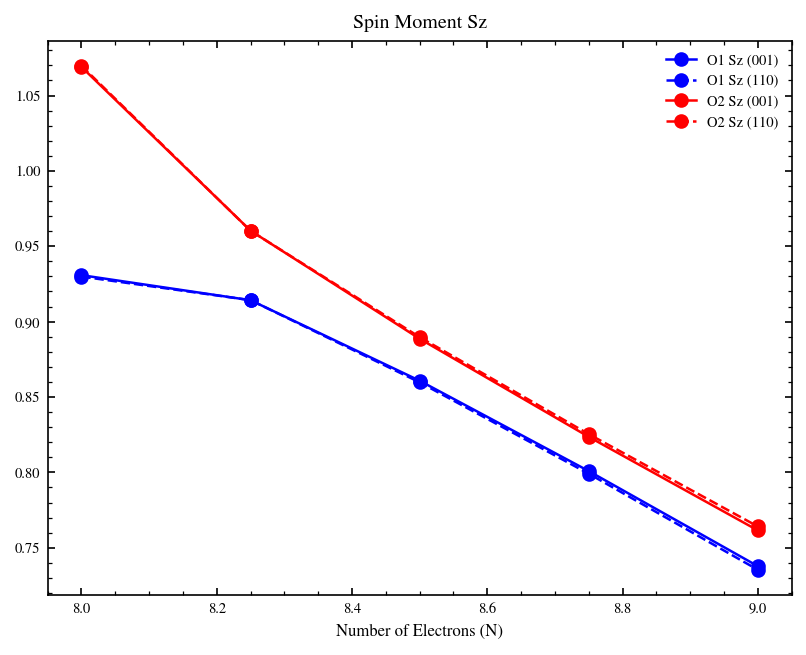

In [ ]:
fig1, ax1 = plt.subplots()

ax1.plot(all_gs_001["N"], all_gs_001["O1_Sz"], marker='o', c="blue")
ax1.plot(all_gs_110["N"], all_gs_110["O1_Sz"], marker='o', linestyle='--', c="blue")
ax1.plot(all_gs_001["N"], all_gs_001["O2_Sz"], marker='o', c="red")
ax1.plot(all_gs_110["N"], all_gs_110["O2_Sz"], marker='o', linestyle='--', c="red")

ax1.set_title("Spin Moment Sz")
ax1.legend(["O1 Sz (001)", "O1 Sz (110)", "O2 Sz (001)", "O2 Sz (110)"])
ax1.set_xlabel("Number of Electrons (N)")

Text(0.5, 0, 'Number of Electrons (N)')

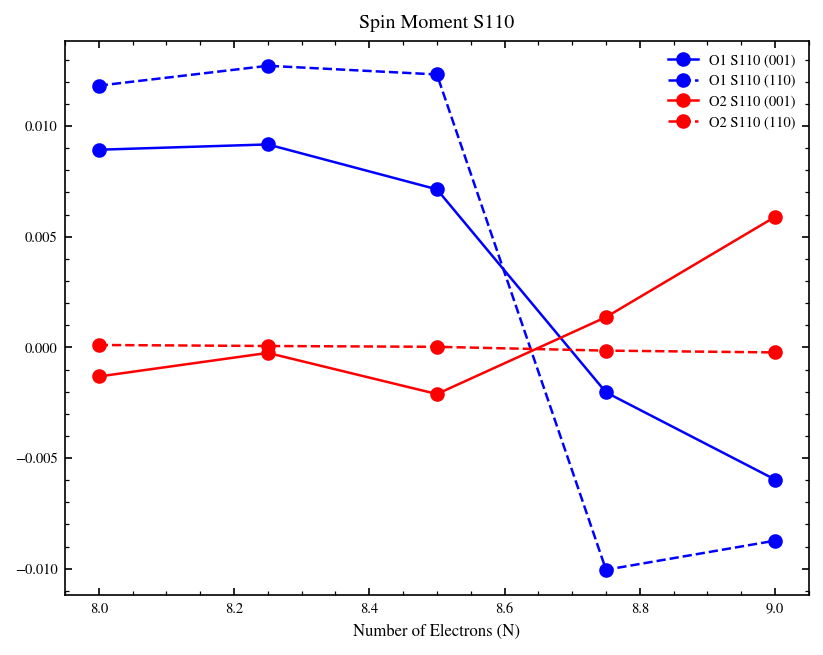

In [ ]:
fig1, ax1 = plt.subplots()

ax1.plot(all_gs_001["N"], all_gs_001["O1_S110"], marker='o', c="blue")
ax1.plot(all_gs_110["N"], all_gs_110["O1_S110"], marker='o', linestyle='--', c="blue")
ax1.plot(all_gs_001["N"], all_gs_001["O2_S110"], marker='o', c="red")
ax1.plot(all_gs_110["N"], all_gs_110["O2_S110"], marker='o', linestyle='--', c="red")

ax1.set_title("Spin Moment S110")
ax1.legend(["O1 S110 (001)", "O1 S110 (110)", "O2 S110 (001)", "O2 S110 (110)"])
ax1.set_xlabel("Number of Electrons (N)")

In [ ]:
all_gs_001.columns

Index(['N', 'spin_dir', 'Seed', 'Energy', 'Threshold', 'Rho2Trace', 'O1_Lx',
       'O1_Ly', 'O1_Lz', 'O1_L110', 'O1_Sx', 'O1_Sy', 'O1_Sz', 'O1_S110',
       'O2_Lx', 'O2_Ly', 'O2_Lz', 'O2_L110', 'O2_Sx', 'O2_Sy', 'O2_Sz',
       'O2_S110', 'occ1_yz_up', 'occ1_yz_down', 'occ1_zx_up', 'occ1_zx_down',
       'occ1_xy_up', 'occ1_xy_down', 'occ2_yz_up', 'occ2_yz_down',
       'occ2_zx_up', 'occ2_zx_down', 'occ2_xy_up', 'occ2_xy_down ',
       'lowest_bin_count', 'total_count'],
      dtype='str')

Text(0.5, 0, 'Number of Electrons (N)')

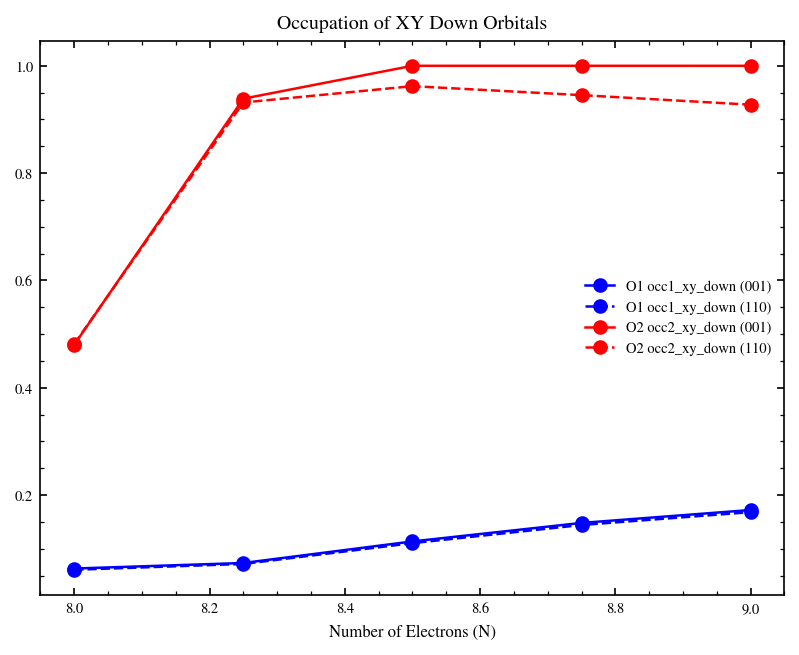

In [ ]:
fig1, ax1 = plt.subplots()

ax1.plot(all_gs_001["N"], all_gs_001["occ1_xy_down"], marker='o', c="blue")
ax1.plot(all_gs_110["N"], all_gs_110["occ1_xy_down"], marker='o', linestyle='--', c="blue")
ax1.plot(all_gs_001["N"], all_gs_001["occ2_xy_down "], marker='o', c="red")
ax1.plot(all_gs_110["N"], all_gs_110["occ2_xy_down "], marker='o', linestyle='--', c="red")

ax1.set_title("Occupation of XY Down Orbitals")
ax1.legend(["O1 occ1_xy_down (001)", "O1 occ1_xy_down (110)", "O2 occ2_xy_down (001)", "O2 occ2_xy_down (110)"])
ax1.set_xlabel("Number of Electrons (N)")

Text(0.5, 0, 'Number of Electrons (N)')

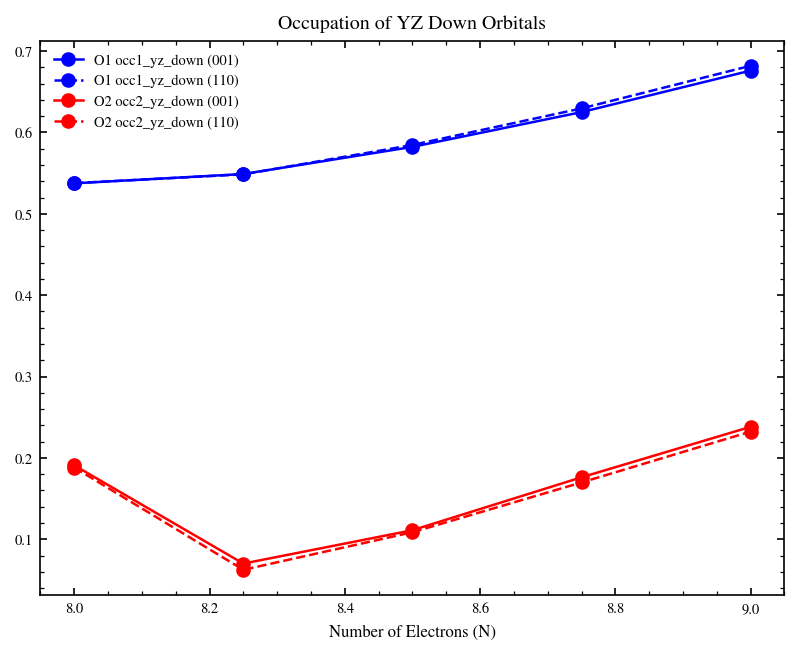

In [ ]:
fig1, ax1 = plt.subplots()

ax1.plot(all_gs_001["N"], all_gs_001["occ1_yz_down"], marker='o', c="blue")
ax1.plot(all_gs_110["N"], all_gs_110["occ1_yz_down"], marker='o', linestyle='--', c="blue")
ax1.plot(all_gs_001["N"], all_gs_001["occ2_yz_down"], marker='o', c="red")
ax1.plot(all_gs_110["N"], all_gs_110["occ2_yz_down"], marker='o', linestyle='--', c="red")

ax1.set_title("Occupation of YZ Down Orbitals")
ax1.legend(["O1 occ1_yz_down (001)", "O1 occ1_yz_down (110)", "O2 occ2_yz_down (001)", "O2 occ2_yz_down (110)"])
ax1.set_xlabel("Number of Electrons (N)")

Text(0.5, 0, 'Number of Electrons (N)')

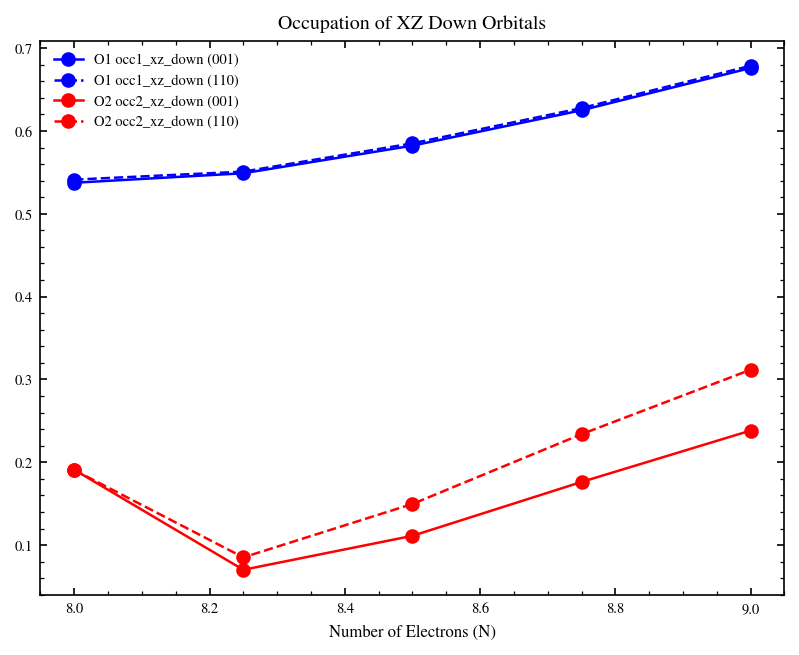

In [ ]:
fig1, ax1 = plt.subplots()

ax1.plot(all_gs_001["N"], all_gs_001["occ1_zx_down"], marker='o', c="blue")
ax1.plot(all_gs_110["N"], all_gs_110["occ1_zx_down"], marker='o', linestyle='--', c="blue")
ax1.plot(all_gs_001["N"], all_gs_001["occ2_zx_down"], marker='o', c="red")
ax1.plot(all_gs_110["N"], all_gs_110["occ2_zx_down"], marker='o', linestyle='--', c="red")

ax1.set_title("Occupation of XZ Down Orbitals")
ax1.legend(["O1 occ1_xz_down (001)", "O1 occ1_xz_down (110)", "O2 occ2_xz_down (001)", "O2 occ2_xz_down (110)"])
ax1.set_xlabel("Number of Electrons (N)")

## Sweeping CF1 and CF2 Analysis

In [24]:
#get_gs_row(ffolder, fpath):
import glob
import os
import re

def parse_csv_files(folder):
    pattern = re.compile(
        r'(?P<direction>\d{3})gsoutCF1=(?P<cf1>-?\d+\.?\d*)CF2=(?P<cf2>-?\d+\.?\d*)\.csv'
    )

    results = []
    search_path = os.path.join(folder, "*.csv")
    for filepath in glob.glob(search_path):
        filename = os.path.basename(filepath)
        m = pattern.search(filename)
        if m:
            results.append({
                "file": filepath,
                "direction": m.group("direction"),      # e.g. "001" or "110"
                "CF1": float(m.group("cf1")),
                "CF2": float(m.group("cf2")),
            })
        else:
            print(f"Warning: filename did not match pattern: {filename}")

    return results


# Usage
folder = "/home/cmp/Documents/Github/Stoner-SCF/out/sweeps/CFSweep"
results = parse_csv_files(folder)

df_cf_results = pd.DataFrame(results)

df_cf_results.head()

,file,direction,CF1,CF2
0,/home/cmp/Documents/Github/Stoner-SCF/out/swee...,110,0.00,-0.14
1,/home/cmp/Documents/Github/Stoner-SCF/out/swee...,110,0.25,-0.35
2,/home/cmp/Documents/Github/Stoner-SCF/out/swee...,110,0.01,-0.07
3,/home/cmp/Documents/Github/Stoner-SCF/out/swee...,110,0.05,-0.15
4,/home/cmp/Documents/Github/Stoner-SCF/out/swee...,001,0.30,-0.20


In [25]:
df_cf_results.iloc[0]["file"]

'/home/cmp/Documents/Github/Stoner-SCF/out/sweeps/CFSweep/110gsoutCF1=0.0CF2=-0.14.csv'

In [26]:
def get_gs_row_path(fpath):
    df = pd.read_csv(fpath)
    df = df[(np.abs(df["Energy"]) > 1e-3) & (np.abs(df["Energy"]) < 1e10)].copy()

    if df.empty:
        raise ValueError(f"No converged rows in {fpath}")

    gs_row = df.loc[df["Energy"].idxmin()]

    n_bins = 5
    df["energy_bin"] = pd.cut(df["Energy"], bins=n_bins)
    counts = df["energy_bin"].value_counts().sort_index()

    return gs_row, counts.iloc[0], len(df)

In [27]:
def add_gs_columns(files_df):
    gs_rows = []
    lowest_bin_counts = []
    n_rows_list = []
    valid_idx = []

    for idx, row in files_df.iterrows():
        try:
            gs_row, lowest_bin_count, n_rows = get_gs_row_path(row["file"])
        except ValueError as e:
            print(f"Skipping {row['file']}: {e}")
            continue

        gs_rows.append(gs_row)
        lowest_bin_counts.append(lowest_bin_count)
        n_rows_list.append(n_rows)
        valid_idx.append(idx)

    gs_df = pd.DataFrame(gs_rows, index=valid_idx)
    gs_df["lowest_bin_count"] = lowest_bin_counts
    gs_df["n_rows"] = n_rows_list

    return files_df.loc[valid_idx].join(gs_df)


# Usage
result_df = add_gs_columns(df_cf_results)

In [28]:
result_df.head()

,file,direction,CF1,CF2,Seed,Energy,Threshold,Rho2Trace,O1_Lx,O1_Ly,...,occ1_xy_up,occ1_xy_down,occ2_yz_up,occ2_yz_down,occ2_zx_up,occ2_zx_down,occ2_xy_up,occ2_xy_down,lowest_bin_count,n_rows
0,/home/cmp/Documents/Github/Stoner-SCF/out/swee...,110,0.00,-0.14,0.0,21.748802,1.000000e-07,7.282879,0.045424,1.187432e-08,...,0.999985,0.322101,0.999985,0.045951,0.999984,0.057529,0.999845,0.989117,16,32
1,/home/cmp/Documents/Github/Stoner-SCF/out/swee...,110,0.25,-0.35,4.0,21.483129,1.000000e-07,7.660018,0.054920,8.409743e-08,...,0.999982,0.062407,0.999985,0.002537,0.999985,0.003315,0.999902,0.999024,27,28
2,/home/cmp/Documents/Github/Stoner-SCF/out/swee...,110,0.01,-0.07,10.0,21.797385,1.000000e-07,6.899853,0.147351,-7.046839e-08,...,0.999981,0.231147,0.999979,0.233200,0.999986,0.252186,0.999978,0.450750,7,24
3,/home/cmp/Documents/Github/Stoner-SCF/out/swee...,110,0.05,-0.15,9.0,21.738628,1.000000e-07,7.291386,0.042110,-4.704550e-07,...,0.999986,0.265587,0.999985,0.041655,0.999984,0.050975,0.999848,0.991149,20,30
4,/home/cmp/Documents/Github/Stoner-SCF/out/swee...,001,0.30,-0.20,0.0,21.596643,1.000000e-07,7.814516,0.000003,-3.170082e-07,...,0.999973,0.002751,1.000000,0.005279,1.000000,0.005279,0.999804,0.928823,30,31


In [29]:
def compute_mca_CF(result_df):
    pivot = result_df.pivot(index=["CF1", "CF2"], columns="direction", values="Energy")

    mca_df = pivot.copy()
    mca_df["MCA"] = mca_df["110"] - mca_df["001"]

    return mca_df.reset_index()


# Usage
mca_df = compute_mca_CF(result_df)

In [30]:
mca_df.head()

direction,CF1,CF2,001,110,MCA
0,0.0,-0.20,21.692676,21.692038,-0.000638
1,0.0,-0.19,21.702245,21.701551,-0.000695
2,0.0,-0.18,21.711810,21.711047,-0.000763
3,0.0,-0.17,21.721369,21.720524,-0.000845
4,0.0,-0.16,21.730924,21.729980,-0.000944


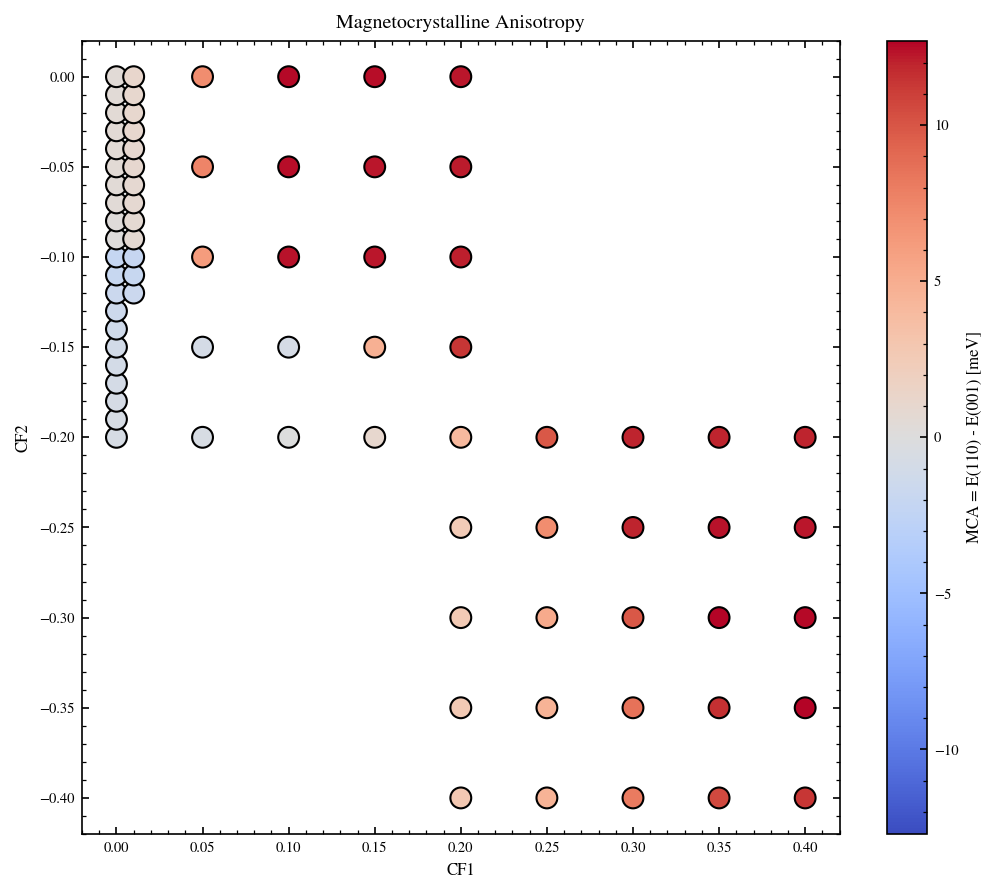

In [31]:


from matplotlib.colors import TwoSlopeNorm


def plot_mca(mca_df):
    fig, ax = plt.subplots(figsize=(7, 6))

    vmax = mca_df["MCA"].abs().max()*1e3
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    sc = ax.scatter(
        mca_df["CF1"],
        mca_df["CF2"],
        c=mca_df["MCA"]*1e3,  # Convert to meV
        cmap="coolwarm",
        norm=norm,
        s=100,
        edgecolors="k",
    )

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("MCA = E(110) - E(001) [meV]")

    ax.set_xlabel("CF1")
    ax.set_ylabel("CF2")
    ax.set_title("Magnetocrystalline Anisotropy")

    plt.tight_layout()
    plt.show()


# Usage
plot_mca(mca_df)